# Get the Data
*Our task is to predict median house values in Californian districts, given a number of features from these districts.*

## Download the data

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import tarfile
import urllib.request

In [2]:
def load_housing_data():
    tarball_path = Path("../datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("../datasets").mkdir(parents=True,exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
    with tarfile.open(tarball_path) as f:
        f.extractall(path="../datasets")
    return pd.read_csv(Path("../datasets/housing/housing.csv"))

In [3]:
housing = load_housing_data()

## Take a Quick Look at the Data

In [4]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [7]:
housing.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


In [8]:
# Code to save figures
IMAGES_PATH = Path("../") / "images"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png"):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension)

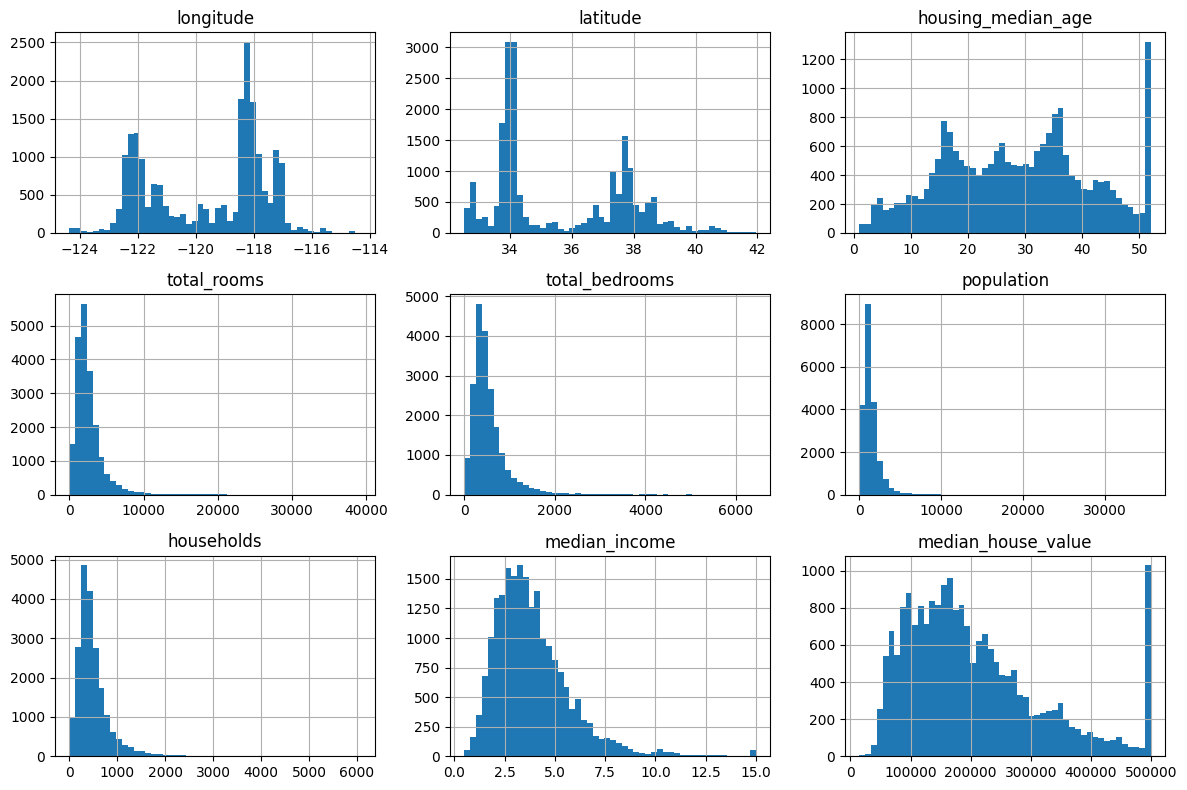

In [9]:
import matplotlib.pyplot as plt

housing.hist(bins=50,figsize=(12, 8))
save_fig("attribute_histogram_plots")
plt.show()

## Create a Test Set
Before look at the data any further, we need to create a test set, put it aside, and never look at it. We uses stratified sampling to spli data by creation new "income_cat" column. We believed that income is the best feature to predict median house value,and it should be split evenly beltween train and test. that's why we uses income.

In [10]:
housing["income_cat"] = pd.cut(housing["median_income"],
                              bins=[0., 1.5, 3.0, 4.5, 6.0, np.inf],
                              labels=[1,2,3,4,5])

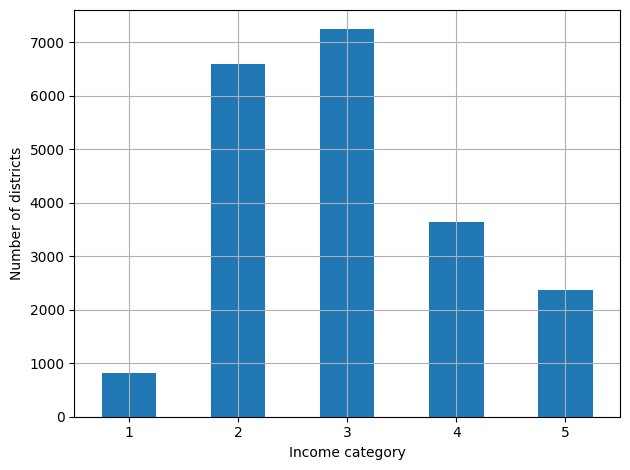

In [11]:
housing["income_cat"].value_counts().sort_index().plot.bar(rot=0,grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
save_fig("housing_income_cat_bar_plot")
plt.show()

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
strat_train_set, strat_test_set = train_test_split(
    housing, test_size=0.2, stratify=housing["income_cat"], random_state=42)

In [14]:
strat_test_set["income_cat"].value_counts().sort_index() / len(strat_test_set)

income_cat
1    0.039971
2    0.318798
3    0.350533
4    0.176357
5    0.114341
Name: count, dtype: float64

In [15]:
strat_train_set["income_cat"].value_counts().sort_index() / len(strat_train_set)

income_cat
1    0.039789
2    0.318859
3    0.350594
4    0.176296
5    0.114462
Name: count, dtype: float64

We can observe that train and test are evenly splitted.

In [16]:
# There is no need of income_cat. so, drop it.
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

# Discover and Visualize the Data to Gain Insights

In [17]:
# we are going to experiment with various transformations of training set, we we make a copy of original train set. we can revert to it afterwards
housing = strat_train_set.copy()

## Visualizing Geographical Data

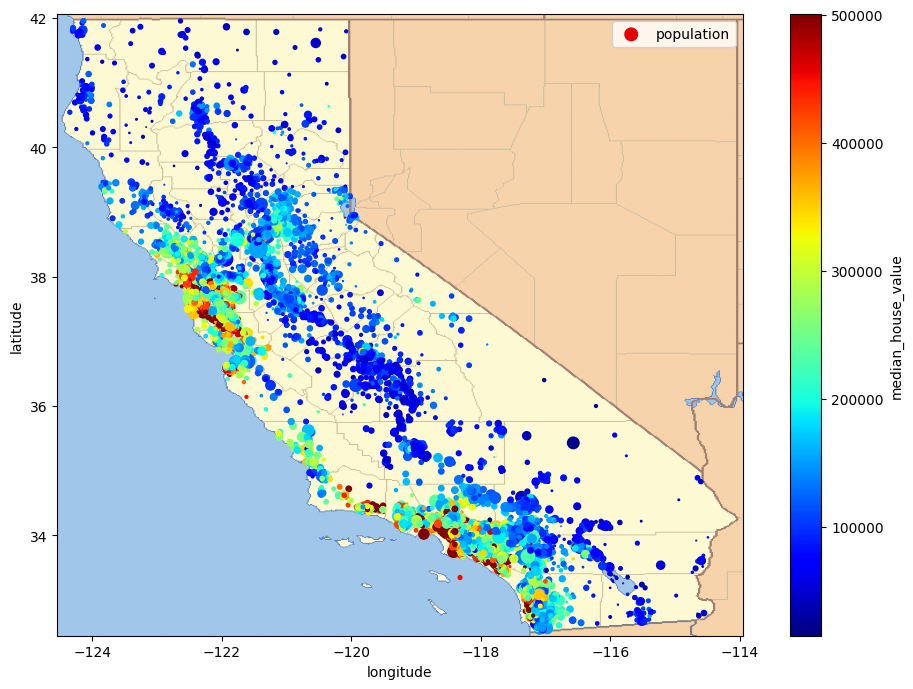

In [18]:
# Download california image
img_path = Path("../images/california.png")
if not img_path.is_file():
    Path("../images").mkdir(parents=True, exist_ok=True)
    url = "https://github.com/ageron/handson-ml3/raw/main/images/end_to_end_project/california.png"
    urllib.request.urlretrieve(url, img_path)
# plot scatter plot
housing.plot(
    kind="scatter", x = "longitude", y = "latitude",
    s = housing["population"] / 100, label="population",
    c = "median_house_value", cmap = "jet", colorbar=True,
    legend=True, sharex=False,figsize=(10, 7)
)
# plot image
california_img = plt.imread(img_path)
axis = min(housing["longitude"])-0.20, max(housing["longitude"])+0.54, min(housing["latitude"])-0.10, max(housing["latitude"])+0.10
plt.axis(axis)
plt.imshow(california_img,extent=axis)
save_fig("california_housing_prices_plot")
plt.show()

## Looking for Correlations

In [19]:
corr = housing.corr(numeric_only=True)

In [20]:
# show the correlation related to median_house_value
corr["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

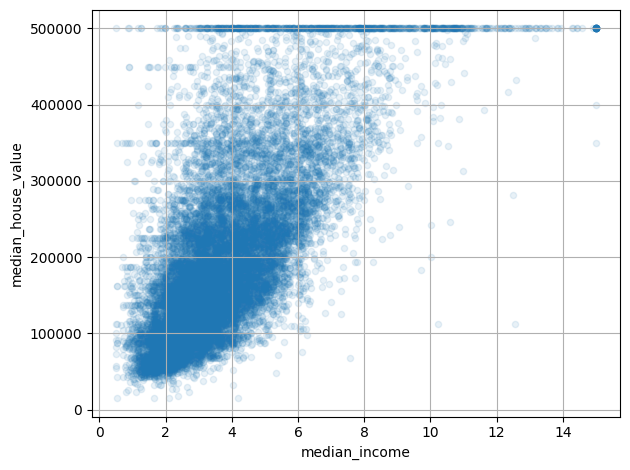

In [21]:
housing.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.1, grid=True)
save_fig("income_vs_house_value_scatterplot")
plt.show()

We can observe that median_house_value highly correlated to median_income

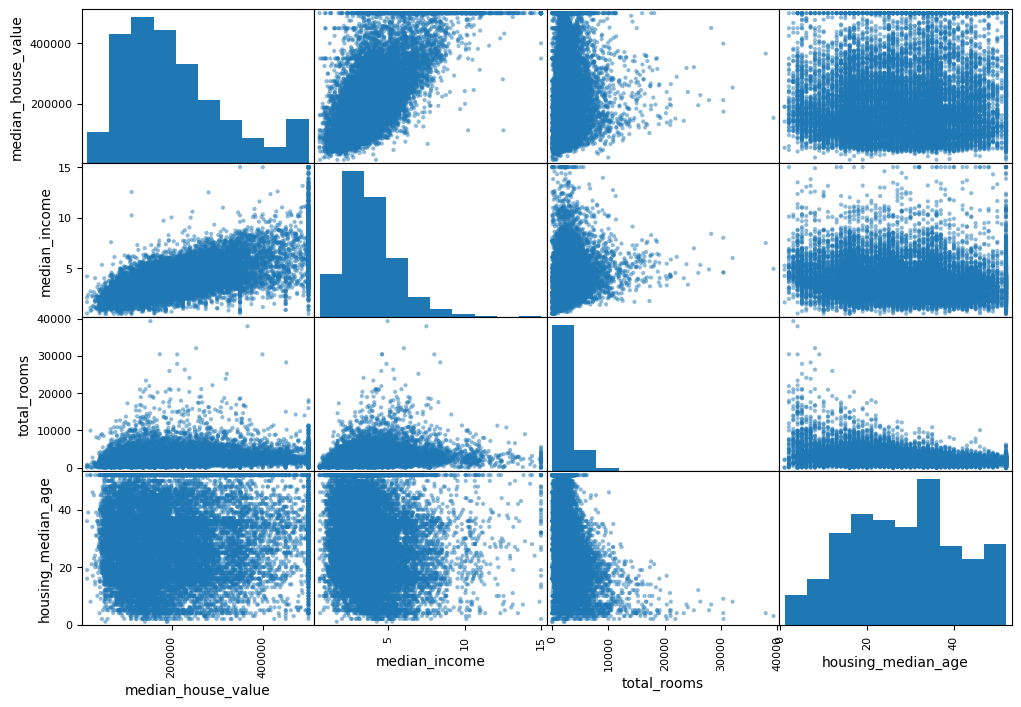

In [22]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
plt.show()

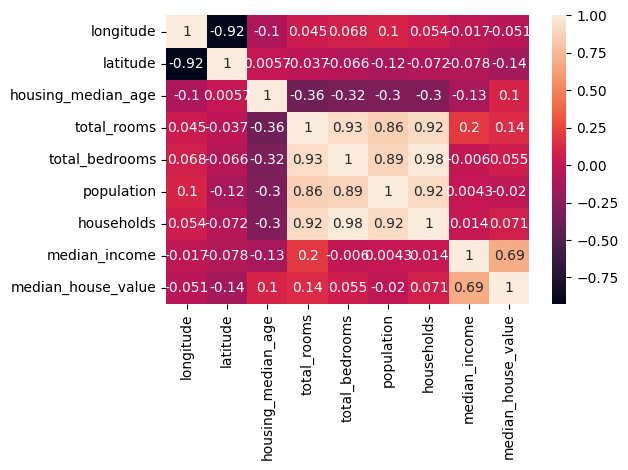

In [23]:
import seaborn as sns

sns.heatmap(corr,annot=True)
save_fig("correlation_plot")
plt.show()

## Experimenting with Attribute Combinations

In [24]:
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]

In [25]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
rooms_per_house       0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
people_per_house     -0.038224
longitude            -0.050859
latitude             -0.139584
bedrooms_ratio       -0.256397
Name: median_house_value, dtype: float64

The new bedrooms_ratio attribute is much more correlated with the median house value than the total number of rooms or bedrooms.
Apparently houses with a lower bedroom/room ratio tend to be more expensive. The number of rooms per household is also more informative than the total number of rooms in a district—obviously the larger the houses, the more expensive they are.

# Prepare the Data for Machine Learning Algorithms

In [26]:
# Let's revert to original training set and seperate the target.
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

## Data Transformation
previously we observed that some data was skewed. so, now we try log transformation on "population" attribute to show how data changes. In the pipeline we apply log transformation for all skewed attributes.

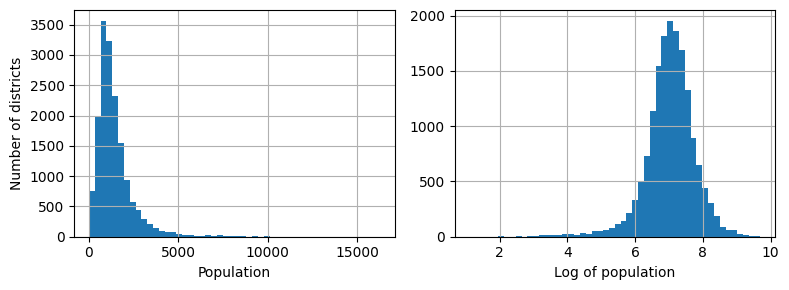

In [27]:
fig, axs = plt.subplots(1,2, figsize=(8, 3))
housing["population"].hist(bins=50,ax= axs[0])
housing["population"].apply(np.log).hist(bins=50,ax= axs[1])
axs[0].set_xlabel("Population")
axs[1].set_xlabel("Log of population")
axs[0].set_ylabel("Number of districts")
save_fig("population_log_transformation")
plt.show()

## Custom Transformers
the following code demonstrates custom transformer that uses a KMeans clusterer in the fit() method to identify the main clusters in the training data, and then uses rbf_kernel() in the transform() method to measure how similar each sample is to each clustercenter

In [28]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self,n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state
        
    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters,n_init=10, random_state= self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self # always return self
        
    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)
        
    def get_feature_names_out(self, names = None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

In [29]:
cluster_simil = ClusterSimilarity(random_state=42)
similarities = cluster_simil.fit_transform(housing[["latitude", "longitude"]])
pd.DataFrame(similarities[:3].round(2),columns=cluster_simil.get_feature_names_out())

,Cluster 0 similarity,Cluster 1 similarity,Cluster 2 similarity,Cluster 3 similarity,Cluster 4 similarity,Cluster 5 similarity,Cluster 6 similarity,Cluster 7 similarity,Cluster 8 similarity,Cluster 9 similarity
0,0.00,0.97,0.00,0.00,0.0,0.08,0.0,0.00,0.13,0.57
1,0.12,0.00,0.98,0.03,0.0,0.00,0.0,0.54,0.00,0.00
2,0.00,0.75,0.00,0.00,0.0,0.44,0.0,0.00,0.27,0.28


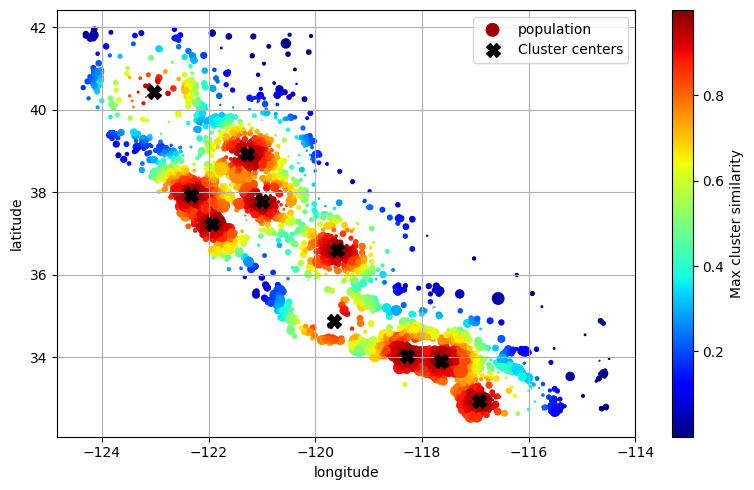

In [30]:
housing_1 = housing.copy()
housing_1["Max cluster similarity"] = similarities.max(axis=1)
housing_1.plot(
    kind="scatter", x = "longitude", y = "latitude", grid=True,
    s = housing["population"] / 100, label="population",
    c = "Max cluster similarity", cmap = "jet", colorbar=True,
    legend=True, sharex=False,figsize=(8, 5)
)
plt.plot(cluster_simil.kmeans_.cluster_centers_[:,1], 
         cluster_simil.kmeans_.cluster_centers_[:,0],
         linestyle="", color="black", marker="X", markersize=10,
         label="Cluster centers")
plt.legend()
save_fig("district_cluster_plot")
plt.show()

## Transformation Pipelines

These are the things we did in below pipeline:
- Missing values in numerical features will be imputed by replacing them
with the median, as most ML algorithms don’t expect missing values. In
categorical features, missing values will be replaced by the most
frequent category.
- The categorical feature will be one-hot encoded, as most ML algorithms
only accept numerical inputs.
- A few ratio features will be computed and added: bedrooms_ratio,
rooms_per_house, and people_per_house. Hopefully these will better
correlate with the median house value, and thereby help the ML models.
- A few cluster similarity features will also be added. These will likely be
more useful to the model than latitude and longitude.
- Features with a long tail will be replaced by their logarithm, as most
models prefer features with roughly uniform or Gaussian distributions.
All numerical features will be standardized, as most ML algorithms
prefer when all features have roughly the same scale.

In [31]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer

In [32]:
def column_ratio(X):
    return X[:,[0]] / X[:,[1]]
    
def ratio_name(function_transformer, feature_names_in):
    return ["ratio"] # feature names out
    
def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy='median'),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler()
    )

log_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler()
)

cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
default_num_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)
cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown='ignore')
)

In [33]:
preprocessing = ColumnTransformer([
        ("bedrooms", ratio_pipeline(), ["total_bedrooms","total_rooms"]),
        ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
        ("people_per_house", ratio_pipeline(), ["population", "households"]),
        ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population",
                               "households", "median_income"]),
        ("geo",cluster_simil, ["latitude", "longitude"]),
        ("cat", cat_pipeline, make_column_selector(dtype_include=object))
    ],
    remainder=default_num_pipeline) # one column remaining: housing_median_age

In [34]:
housing_prepared = preprocessing.fit_transform(housing)
housing_prepared.shape

(16512, 24)

In [35]:
preprocessing.get_feature_names_out()

array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__Cluster 0 similarity',
       'geo__Cluster 1 similarity', 'geo__Cluster 2 similarity',
       'geo__Cluster 3 similarity', 'geo__Cluster 4 similarity',
       'geo__Cluster 5 similarity', 'geo__Cluster 6 similarity',
       'geo__Cluster 7 similarity', 'geo__Cluster 8 similarity',
       'geo__Cluster 9 similarity', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND',
       'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN',
       'remainder__housing_median_age'], dtype=object)

# Select and Train a Model

## Training and Evaluating on the Training Set

### LinearRegression

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

lin_reg = make_pipeline(
    preprocessing, LinearRegression()
)
lin_reg.fit(housing, housing_labels)

,steps,"[('columntransformer', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,remainder,Pipeline(step...ardScaler())])
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [37]:
# predict first 5 training samples with linear model and compare with actual value.
housing_predictions = lin_reg.predict(housing)
print(housing_predictions[:5].round(-2)) # -2 = rounded to the nearest hundred
housing_labels[:5].values

[242800. 375900. 127500.  99400. 324600.]


array([458300., 483800., 101700.,  96100., 361800.])

In [38]:
# Find root mean squared error
lin_rmse = root_mean_squared_error(housing_labels, housing_predictions)
lin_rmse

68647.95686706704

It is not a great score. the median_housing_values of most districts range between 120,000 and 265,000, so a typical prediction error of $68,628 is really not very satisfying. This model underfitting the training data. so, we try more complex model which is DecisionTreeRegressor.

### DecisionTreeRegressor

In [39]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(
    preprocessing, DecisionTreeRegressor(random_state=42)
)
tree_reg.fit(housing,housing_labels)

,steps,"[('columntransformer', ...), ('decisiontreeregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,remainder,Pipeline(step...ardScaler())])
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [40]:
housing_predictions = tree_reg.predict(housing)
tree_rmse = root_mean_squared_error(housing_labels, housing_predictions)
tree_rmse

0.0

Error is 0.0 . Maybe model is overfitting. our can't said with training data. but we can't touch test data until we are ready to launch a model we are confident about, so we need to use part of the training set for training and part of it for model validation.

## Better Evaluation Using Cross-Validation

In [41]:
from sklearn.model_selection import cross_val_score

tree_rmses = -cross_val_score(tree_reg,housing, housing_labels,
                              scoring="neg_root_mean_squared_error", cv=10)

Scikit-Learn’s cross-validation features expect a utility function (greater is better) rather
than a cost function (lower is better), so the scoring function is actually the opposite of the
RMSE. It’s a negative value, so you need to switch the sign of the output to get the RMSE
scores.

In [42]:
pd.Series(tree_rmses).describe()

count       10.000000
mean     66366.983603
std       1976.844743
min      63557.655007
25%      65004.623899
50%      65886.897085
75%      68129.026040
max      69530.301101
dtype: float64

We can observe that it is not even a good model. Infact it's performence similar to Linear Regression.  

### RandomForestRegressor

In [43]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(preprocessing,
                           RandomForestRegressor(random_state=42))
forest_rmses = -cross_val_score(forest_reg, housing, housing_labels,
                                scoring="neg_root_mean_squared_error", cv=10)

In [44]:
pd.Series(forest_rmses).describe()

count       10.000000
mean     46938.209246
std       1018.397196
min      45522.649195
25%      46291.334639
50%      47021.703303
75%      47321.521991
max      49140.832210
dtype: float64

random forests look's better. But ,we are train a RandomForest and measure the RMSE on the training set, that’s much lower, meaning that there’s still quite a lot of overfitting going on. Possible solutions are to simplify the model, constrain it (i.e., regularize it),

# Fine-Tune Our Model
### Randomized Search

In [47]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from scipy.stats import randint

In [48]:
full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42)),
])

In [49]:
param_distribs = {'preprocessing__geo__n_clusters': randint(low=3, high=50),
                  'random_forest__max_features': randint(low=2, high=20)}

rnd_search = RandomizedSearchCV(
    full_pipeline, param_distributions=param_distribs, n_iter=10, cv=3,
    scoring='neg_root_mean_squared_error', random_state=42)

rnd_search.fit(housing, housing_labels)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'preprocessing__geo__n_clusters': <scipy.stats....x746888a64ac0>, 'random_forest__max_features': <scipy.stats....x746888a64a00>}"
,n_iter,10
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [50]:
cv_res = pd.DataFrame(rnd_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
cv_res.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessing__geo__n_clusters,param_random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
1,15.173734,0.178372,0.176833,0.009191,45,9,"{'preprocessing__geo__n_clusters': 45, 'random...",-41224.050287,-42385.046696,-42711.986848,-42107.027943,638.466717,1
8,11.708213,0.307947,0.174629,0.008883,32,7,"{'preprocessing__geo__n_clusters': 32, 'random...",-41373.971481,-42579.487116,-43229.716998,-42394.391865,768.827265,2
0,23.507473,3.029040,0.191061,0.014323,41,16,"{'preprocessing__geo__n_clusters': 41, 'random...",-42397.277866,-42640.399651,-43175.094475,-42737.590664,324.894074,3
5,7.836418,0.847663,0.185401,0.026632,42,4,"{'preprocessing__geo__n_clusters': 42, 'random...",-41873.819760,-43347.904502,-43689.910761,-42970.545008,787.970715,4
2,12.758541,0.535895,0.229805,0.047842,23,8,"{'preprocessing__geo__n_clusters': 23, 'random...",-42420.517191,-43137.567362,-43585.144979,-43047.743177,479.680977,5


## Analyze the Best Models and Their Errors

In [51]:
final_model = rnd_search.best_estimator_  # includes preprocessing
feature_importances = final_model["random_forest"].feature_importances_

In [57]:
feature_importances = pd.DataFrame(feature_importances,columns=["feature_importance"],index=final_model["preprocessing"].get_feature_names_out())
feature_importances = feature_importances.sort_values(by="feature_importance",ascending=False)
feature_importances.head()

,feature_importance
log__median_income,0.188830
cat__ocean_proximity_INLAND,0.075507
bedrooms__ratio,0.064271
rooms_per_house__ratio,0.052170
people_per_house__ratio,0.046643


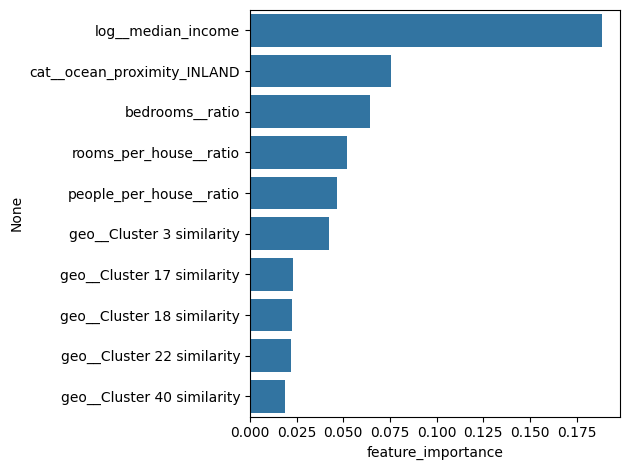

In [64]:
sns.barplot(y=feature_importances.index[:10],x=feature_importances["feature_importance"][:10])
save_fig("random_forest_feature_importance")
plt.show()

## Evaluate our System on the Test Set

In [65]:
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

final_predictions = final_model.predict(X_test)

final_rmse = root_mean_squared_error(y_test, final_predictions)
print(final_rmse)

41556.053474456494


# Save the model

In [66]:
import joblib

model_dir = Path("../backend/model")
model_dir.mkdir(parents=True, exist_ok=True)
model_path = model_dir /"my_california_housing_model.pkl"
joblib.dump(final_model, model_path)

['my_california_housing_model.pkl']